# 1. Data Loading and Corpus Processing

In [1]:
from google.colab import drive
import os
import json
import pandas as pd
import re
import string
import numpy as np
import matplotlib.pyplot as plt
import torch
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer



# print("Mounting Google Drive...")
# drive.mount('/content/drive')

# Only these keys are actual 10-K sections — everything else is metadata
SECTION_KEYS = [
    "item_1", "item_1A", "item_1B", "item_2", "item_3", "item_4",
    "item_5", "item_6", "item_7", "item_7A", "item_8", "item_9",
    "item_9A", "item_9B", "item_10", "item_11", "item_12",
    "item_13", "item_14", "item_15"
]

def process_data(drive_folder_path, output_csv="data/corpus.csv"):
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    documents = []

    if not os.path.exists(drive_folder_path):
        print(f"Error: Could not find the directory at '{drive_folder_path}'.")
        return None

    file_list = [f for f in os.listdir(drive_folder_path) if f.endswith('.json')]
    print(f"Found {len(file_list)} JSON files. Starting processing...")

    for file_name in file_list:
        file_path = os.path.join(drive_folder_path, file_name)

        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                continue

        cik = str(data.get("cik", file_name.split("_")[0]))

        # Only iterate over known section keys, skip all metadata
        for section_key in SECTION_KEYS:
            section_text = data.get(section_key, "")

            if not isinstance(section_text, str) or len(section_text) < 200:
                continue

            clean_text = re.sub(r'\s+', ' ', section_text).strip()
            doc_id = f"{cik}_{section_key}"

            documents.append({
                "doc_id": doc_id,
                "text": clean_text
            })

    df = pd.DataFrame(documents)
    df.to_csv(output_csv, index=False)
    print(f"Success! Processed {len(df)} document chunks saved to {output_csv}")
    return df

drive_path = "/content/drive/MyDrive/extracted"
df_corpus = process_data(drive_folder_path=drive_path)

if df_corpus is not None:
    display(df_corpus.head())

Found 191 JSON files. Starting processing...
Success! Processed 2807 document chunks saved to data/corpus.csv


,doc_id,text
0,1036188_item_1,ITEM 1. BUSINESS QAD Inc. (QAD or the Company)...
1,1036188_item_1A,ITEM 1A. RISK FACTORS The environment in which...
2,1036188_item_2,ITEM 2. PROPERTIES QAD’s corporate headquarter...
3,1036188_item_3,ITEM 3. LEGAL PROCEEDINGS We are not party to ...
4,1036188_item_5,"ITEM 5. MARKET FOR REGISTRANT’S COMMON EQUITY,..."


# 2. Text Preprocessing and NLP Setup

In [2]:
# 2. NLP Preprocessing Setup
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    tokens = word_tokenize(text)
    clean_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
        and word not in punctuation
        and word.isalpha()
    ]
    return " ".join(clean_tokens)

print("Starting text preprocessing...")
df_corpus['processed_text'] = df_corpus['text'].apply(preprocess_text)
display(df_corpus[['doc_id', 'text', 'processed_text']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Starting text preprocessing...


,doc_id,text,processed_text
0,1036188_item_1,ITEM 1. BUSINESS QAD Inc. (QAD or the Company)...,item business qad qad company leader enterpris...
1,1036188_item_1A,ITEM 1A. RISK FACTORS The environment in which...,item risk factor environment operate involves ...
2,1036188_item_2,ITEM 2. PROPERTIES QAD’s corporate headquarter...,item property qad corporate headquarters locat...
3,1036188_item_3,ITEM 3. LEGAL PROCEEDINGS We are not party to ...,item legal proceeding party material legal pro...
4,1036188_item_5,"ITEM 5. MARKET FOR REGISTRANT’S COMMON EQUITY,...",item market registrant common equity related s...


In [3]:
!pip install -q rank_bm25

# 3. Lexical Search (BM25) Implementation

In [4]:
# 3. BM25 Search Implementation
from rank_bm25 import BM25Okapi

print("Tokenizing corpus for BM25...")
tokenized_corpus = [str(doc).split() for doc in df_corpus['processed_text'].tolist()]
bm25 = BM25Okapi(tokenized_corpus)

def search_bm25(query, top_k=5):
    processed_query = preprocess_text(query)
    tokenized_query = processed_query.split()
    doc_scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(doc_scores)[-top_k:][::-1]

    results = []
    for idx in top_indices:
        if doc_scores[idx] > 0:
            results.append({
                "doc_id": df_corpus.iloc[idx]['doc_id'],
                "score": doc_scores[idx],
                "text": df_corpus.iloc[idx]['text']
            })
    return results

Tokenizing corpus for BM25...


In [5]:
!pip install -q sentence-transformers

# 4. Dense Retrieval Implementation

In [ ]:
# 4. Dense Embedding Search Implementation
from sentence_transformers import SentenceTransformer, util

print("Loading Embedding Model...")

#bi_encoder = SentenceTransformer('ProsusAI/finbert')
bi_encoder = SentenceTransformer('BAAI/bge-base-en-v1.5')
print("Encoding corpus..")
corpus_texts = df_corpus['text'].tolist()
corpus_embeddings = bi_encoder.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=True)

def search_dense(query, top_k=5):
    query_embedding = bi_encoder.encode(query, convert_to_tensor=True)
    hits = util.semantic_search(query_embedding, corpus_embeddings, top_k=top_k)[0]
    results = []
    for hit in hits:
        idx = hit['corpus_id']
        results.append({
            "doc_id": df_corpus.iloc[idx]['doc_id'],
            "score": hit['score'],
            "text": df_corpus.iloc[idx]['text'],
            "corpus_id": idx
        })
    return results

Loading Embedding Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding corpus..


Batches:   0%|          | 0/88 [00:00<?, ?it/s]

# 5. Re-ranking (Cross-Encoder) Implementation

In [22]:
# 5. Cross-Encoder Re-ranker Implementation
from sentence_transformers import CrossEncoder

print("Loading Cross-Encoder Re-ranker (MiniLM-L12 for better accuracy)...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-12-v2')

def search_retrieve_and_rerank(query, initial_top_k=50, final_top_k=5):
    # Retrieve candidates using our new FinBERT Dense model
    initial_hits = search_dense(query, top_k=initial_top_k)

    # Prepare pairs for re-ranking
    cross_inp = [[query, hit['text']] for hit in initial_hits]
    cross_scores = cross_encoder.predict(cross_inp)

    for idx, hit in enumerate(initial_hits):
        hit['cross_score'] = cross_scores[idx]

    # Re-sort based on the Cross-Encoder's judgment
    reranked_hits = sorted(initial_hits, key=lambda x: x['cross_score'], reverse=True)
    return reranked_hits[:final_top_k]

Loading Cross-Encoder Re-ranker (MiniLM-L12 for better accuracy)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 6. Evaluation Data Generation (Pooling)

In [23]:
import pandas as pd
import numpy as np
import os

print("--- Generating Qrels Pool for Manual Judging ---\n")

# Step 1: Define your 5 queries (same as your evaluation queries)
queries_data = [
    {"query_id": "q1", "query_text": "What are the primary supply chain risks and disruptions?"},
    {"query_id": "q2", "query_text": "Impact of foreign exchange rate fluctuations on revenue."},
    {"query_id": "q3", "query_text": "How is the company utilizing artificial intelligence and machine learning?"},
    {"query_id": "q4", "query_text": "Risks associated with changing government regulations and compliance."},
    {"query_id": "q5", "query_text": "What are the environmental and climate change related risks?"}
]
queries_df = pd.DataFrame(queries_data)

# Save queries.csv while we're at it
os.makedirs("data", exist_ok=True)
queries_df.to_csv("data/queries.csv", index=False)
print(f"Saved: data/queries.csv ({len(queries_df)} queries)")

# Step 2: For each query, retrieve top 10 candidates from ALL three methods
# and pool them together (union) — standard pooling method in IR evaluation
K = 10
pool_records = []

print("Retrieving candidates from all three methods...\n")

for _, row in queries_df.iterrows():
    q_id   = row["query_id"]
    q_text = row["query_text"]

    # Get top-K doc IDs from each method
    bm25_hits   = [r["doc_id"] for r in search_bm25(q_text, top_k=K)]
    dense_hits  = [r["doc_id"] for r in search_dense(q_text, top_k=K)]
    rerank_hits = [r["doc_id"] for r in search_retrieve_and_rerank(q_text, initial_top_k=50, final_top_k=K)]

    # Pool: union of all three, preserving first-seen rank order
    seen = {}
    rank = 1
    for doc_id in bm25_hits + dense_hits + rerank_hits:
        if doc_id not in seen:
            seen[doc_id] = rank
            rank += 1

    for doc_id, doc_rank in seen.items():
        pool_records.append({
            "query_id":   q_id,
            "query_text": q_text,
            "doc_id":     doc_id,
            "rank":       doc_rank
        })

    print(f"  {q_id}: {len(seen)} unique candidates pooled from 3 methods")

# Step 3: Merge in the document text so you can read it while judging
pool_df = pd.DataFrame(pool_records)
pool_df = pool_df.merge(df_corpus[["doc_id", "text"]], on="doc_id", how="left")

# Step 4: Add empty relevance column for you to fill in manually
# Fill with 0 (not relevant) or 1 (relevant) or 2 (highly relevant)
pool_df["relevance"] = ""
pool_df = pool_df[["query_id", "query_text", "doc_id", "rank", "text", "relevance"]]

# Step 5: Save the pool
pool_df.to_csv("data/qrels_pool_for_judging.csv", index=False)
print(f"\nSaved: data/qrels_pool_for_judging.csv")
print(f"Total rows to judge: {len(pool_df)}")

--- Generating Qrels Pool for Manual Judging ---

Saved: data/queries.csv (5 queries)
Retrieving candidates from all three methods...

  q1: 26 unique candidates pooled from 3 methods
  q2: 21 unique candidates pooled from 3 methods
  q3: 21 unique candidates pooled from 3 methods
  q4: 25 unique candidates pooled from 3 methods
  q5: 25 unique candidates pooled from 3 methods

Saved: data/qrels_pool_for_judging.csv
Total rows to judge: 118


# 7. Metric Calculation and System Evaluation

In [24]:
# ---------------------------------------------------------
# 1. Load Queries and Qrels from CSV Files
# ---------------------------------------------------------
queries_path = "data/queries.csv"
qrels_path = "data/qrels.csv"

if not os.path.exists(queries_path) or not os.path.exists(qrels_path):
    print("Error: Could not find queries.csv or qrels.csv in the 'data/' folder.")
    print("Please make sure you run the synthetic qrels generation step first!")
else:
    # Load the DataFrames
    df_queries = pd.read_csv(queries_path)
    df_qrels = pd.read_csv(qrels_path)

    # Convert queries DataFrame to a dictionary
    queries = dict(zip(df_queries['query_id'], df_queries['query_text']))

    # Convert qrels DataFrame to a dictionary
    # We only want to include documents where relevance is 1 (or greater)
    relevant_only = df_qrels[df_qrels['relevance'] >= 1]
    qrels = relevant_only.groupby('query_id')['doc_id'].apply(list).to_dict()

    print(f"Successfully loaded {len(queries)} queries and ground-truth data from files!\n")

# ---------------------------------------------------------
# 2. Define Evaluation Metrics (Updated for K=10)
# ---------------------------------------------------------
def precision_at_k(retrieved_doc_ids, relevant_doc_ids, k=10):
    retrieved_k = retrieved_doc_ids[:k]
    relevant_retrieved = set(retrieved_k).intersection(set(relevant_doc_ids))
    return len(relevant_retrieved) / k

def recall_at_k(retrieved_doc_ids, relevant_doc_ids, k=10):
    if not relevant_doc_ids:
        return 0.0
    retrieved_k = retrieved_doc_ids[:k]
    relevant_retrieved = set(retrieved_k).intersection(set(relevant_doc_ids))
    return len(relevant_retrieved) / len(relevant_doc_ids)

def average_precision(retrieved_doc_ids, relevant_doc_ids, k=10):
    retrieved_k = retrieved_doc_ids[:k]
    score = 0.0
    num_hits = 0.0
    for i, doc_id in enumerate(retrieved_k):
        if doc_id in relevant_doc_ids:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    if not relevant_doc_ids:
        return 0.0
    return score / min(len(relevant_doc_ids), k)

# ---------------------------------------------------------
# 3. Run Evaluation and Compare
# ---------------------------------------------------------
K = 10
results_summary = []

print(f"Evaluating BM25 vs Dense vs Re-Rank across {len(queries)} queries at K={K}...\n")

for q_id, q_text in queries.items():
    relevant_docs = qrels.get(q_id, [])

    if not relevant_docs:
        print(f"Warning: No relevant documents found in qrels for {q_id}. Skipping.")
        continue

    # Get top K results from all methods
    bm25_hits = [res['doc_id'] for res in search_bm25(q_text, top_k=K)]
    dense_hits = [res['doc_id'] for res in search_dense(q_text, top_k=K)]
    rerank_hits = [res['doc_id'] for res in search_retrieve_and_rerank(q_text, initial_top_k=50, final_top_k=K)]

    # Calculate Metrics
    results_summary.append({
        "Query_ID": q_id,
        f"BM25_P@{K}": precision_at_k(bm25_hits, relevant_docs, k=K),
        f"Dense_P@{K}": precision_at_k(dense_hits, relevant_docs, k=K),
        f"Rerank_P@{K}": precision_at_k(rerank_hits, relevant_docs, k=K),
        f"BM25_R@{K}": recall_at_k(bm25_hits, relevant_docs, k=K),
        f"Dense_R@{K}": recall_at_k(dense_hits, relevant_docs, k=K),
        f"Rerank_R@{K}": recall_at_k(rerank_hits, relevant_docs, k=K),
        "BM25_AP": average_precision(bm25_hits, relevant_docs, k=K),
        "Dense_AP": average_precision(dense_hits, relevant_docs, k=K),
        "Rerank_AP": average_precision(rerank_hits, relevant_docs, k=K)
    })

df_eval = pd.DataFrame(results_summary)

mean_metrics = pd.DataFrame({
    "Metric": [f"Mean Precision@{K}", f"Mean Recall@{K}", "Mean Average Precision (MAP)"],
    "BM25": [df_eval[f"BM25_P@{K}"].mean(), df_eval[f"BM25_R@{K}"].mean(), df_eval["BM25_AP"].mean()],
    "Dense Embeddings": [df_eval[f"Dense_P@{K}"].mean(), df_eval[f"Dense_R@{K}"].mean(), df_eval["Dense_AP"].mean()],
    "Re-Rank (Cross-Encoder)": [df_eval[f"Rerank_P@{K}"].mean(), df_eval[f"Rerank_R@{K}"].mean(), df_eval["Rerank_AP"].mean()]
})

print("--- Individual Query Results ---")
display(df_eval)

print("\n--- Overall System Comparison ---")
display(mean_metrics)

os.makedirs("outputs", exist_ok=True)
df_eval.to_csv("outputs/metrics_summary.csv", index=False)
print("\nEvaluation metrics saved to 'outputs/metrics_summary.csv'")

Successfully loaded 5 queries and ground-truth data from files!

Evaluating BM25 vs Dense vs Re-Rank across 5 queries at K=10...

--- Individual Query Results ---


,Query_ID,BM25_P@10,Dense_P@10,Rerank_P@10,BM25_R@10,Dense_R@10,Rerank_R@10,BM25_AP,Dense_AP,Rerank_AP
0,q1,0.9,0.9,0.9,0.391304,0.391304,0.391304,0.835437,0.866389,0.835437
1,q2,1.0,1.0,1.0,0.476190,0.476190,0.476190,1.000000,1.000000,1.000000
2,q3,1.0,1.0,1.0,0.476190,0.476190,0.476190,1.000000,1.000000,1.000000
3,q4,1.0,1.0,1.0,0.400000,0.400000,0.400000,1.000000,1.000000,1.000000
4,q5,0.9,0.1,0.0,1.000000,0.111111,0.000000,0.928263,0.012346,0.000000



--- Overall System Comparison ---


,Metric,BM25,Dense Embeddings,Re-Rank (Cross-Encoder)
0,Mean Precision@10,0.960000,0.800000,0.780000
1,Mean Recall@10,0.548737,0.370959,0.348737
2,Mean Average Precision (MAP),0.952740,0.775747,0.767087



Evaluation metrics saved to 'outputs/metrics_summary.csv'


# 8. Visualization of Results

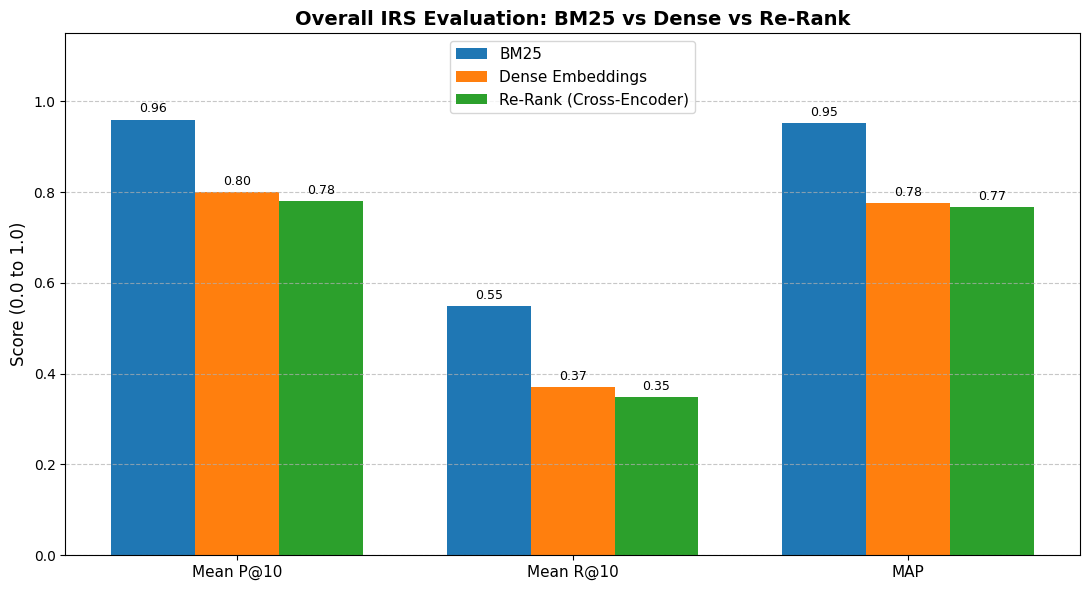

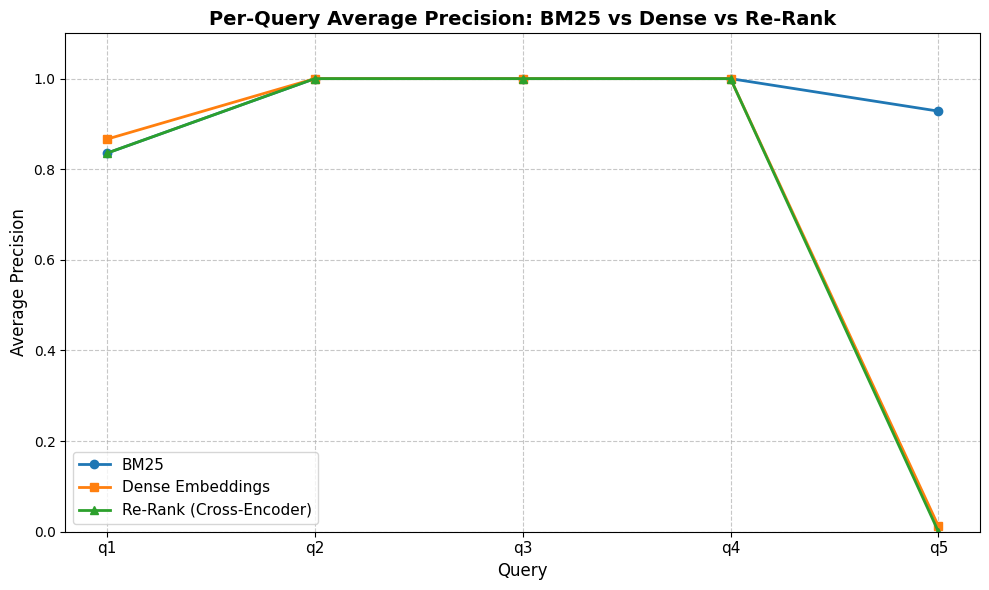

In [25]:
df_eval = pd.read_csv("outputs/metrics_summary.csv")

os.makedirs("outputs", exist_ok=True)

# ---------------------------------------------------------
# Plot 1: Grouped Bar Chart — Overall Mean Metrics
# ---------------------------------------------------------
mean_metrics = {
    "Metric": ["Mean P@10", "Mean R@10", "MAP"],
    "BM25": [df_eval["BM25_P@10"].mean(), df_eval["BM25_R@10"].mean(), df_eval["BM25_AP"].mean()],
    "Dense Embeddings": [df_eval["Dense_P@10"].mean(), df_eval["Dense_R@10"].mean(), df_eval["Dense_AP"].mean()],
    "Re-Rank (Cross-Encoder)": [df_eval["Rerank_P@10"].mean(), df_eval["Rerank_R@10"].mean(), df_eval["Rerank_AP"].mean()]
}
df_mean = pd.DataFrame(mean_metrics)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(df_mean["Metric"]))
width = 0.25

colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
systems = ["BM25", "Dense Embeddings", "Re-Rank (Cross-Encoder)"]
offsets = [-width, 0, width]

for sys, color, offset in zip(systems, colors, offsets):
    rects = ax.bar(x + offset, df_mean[sys], width, label=sys, color=color)
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f"{height:.2f}",
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Score (0.0 to 1.0)", fontsize=12)
ax.set_title("Overall IRS Evaluation: BM25 vs Dense vs Re-Rank", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(df_mean["Metric"], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("outputs/mean_metrics_comparison.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Plot 2: Line Plot — Per-Query Average Precision
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

query_ids = df_eval["Query_ID"]
x_q = np.arange(len(query_ids))

ax.plot(x_q, df_eval["BM25_AP"],   marker="o", linewidth=2, label="BM25",                   color="#1f77b4")
ax.plot(x_q, df_eval["Dense_AP"],  marker="s", linewidth=2, label="Dense Embeddings",        color="#ff7f0e")
ax.plot(x_q, df_eval["Rerank_AP"], marker="^", linewidth=2, label="Re-Rank (Cross-Encoder)", color="#2ca02c")

ax.set_ylabel("Average Precision", fontsize=12)
ax.set_xlabel("Query", fontsize=12)
ax.set_title("Per-Query Average Precision: BM25 vs Dense vs Re-Rank", fontsize=14, fontweight="bold")
ax.set_xticks(x_q)
ax.set_xticklabels(query_ids, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("outputs/per_query_ap_comparison.png", dpi=300)
plt.show()

In [18]:
!pip install -q gradio

# 10. Interactive Search UI (Gradio)

In [27]:
# 6. Gradio UI Layout
import gradio as gr

def format_results_for_ui(results, score_key):
    formatted_data = []
    for i, res in enumerate(results):
        formatted_data.append({
            "Rank": i + 1,
            "Doc ID": res['doc_id'],
            "Score": round(res[score_key], 4),
            "Snippet": res['text'][:200] + "..."
        })
    return pd.DataFrame(formatted_data) if formatted_data else pd.DataFrame([{"Message": "No results"}])

def run_all_searches(query, top_k):
    df_bm25 = format_results_for_ui(search_bm25(query, top_k=int(top_k)), 'score')
    df_dense = format_results_for_ui(search_dense(query, top_k=int(top_k)), 'score')
    df_rerank = format_results_for_ui(search_retrieve_and_rerank(query, initial_top_k=50, final_top_k=int(top_k)), 'cross_score')
    return df_bm25, df_dense, df_rerank

with gr.Blocks() as demo:
    gr.Markdown("# SEC Search Comparison")
    with gr.Row():
        query_input = gr.Textbox(label="Query", scale=4)
        top_k_slider = gr.Slider(1, 10, value=3, label="Top K", scale=1)
    btn = gr.Button("Search")
    with gr.Row():
        with gr.Column():
            gr.Markdown("### BM25")
            bm25_out = gr.Dataframe()
        with gr.Column():
            gr.Markdown("### Bi-Encoder")
            dense_out = gr.Dataframe()
        with gr.Column():
            gr.Markdown("### Cross-Encoder")
            rerank_out = gr.Dataframe()
    btn.click(run_all_searches, [query_input, top_k_slider], [bm25_out, dense_out, rerank_out])

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b0847047d8908073ec.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
